# AIOps Forecasting: JVM OutOfMemory Error Prediction

This notebook applies time-series forecasting to observability metrics in order to predict when JVM heap usage is likely to approach an OutOfMemory (OOM) condition. The analysis compares a classical statistical model (**ARIMA**) with a neural-network model (**LSTM**) to estimate future memory behavior and identify when an operational threshold may be crossed.

In an AIOps setting, this type of forecasting can provide early warning before customer impact occurs. Instead of reacting after a JVM failure, teams can use forecasted threshold crossings to take preventive action such as fixing a memory leak, adjusting heap limits, restarting a service, or scaling capacity.


## Business Understanding

Modern production systems continuously emit infrastructure and application metrics that often contain early warning signals for service degradation or failure. The business objective of this notebook is to forecast JVM heap growth so that likely OutOfMemory conditions can be detected before they occur. In an observability and AIOps context, this supports proactive remediation, reduces downtime, improves reliability, and gives operations teams actionable lead time instead of forcing reactive recovery after failure.


## Key Learning Insights

Key lessons from model development and experimentation:

- **Data window size matters:** Increasing training duration significantly improved both ARIMA and LSTM performance.
- **Model strengths differ:** ARIMA captures trend direction well, while LSTM better models non-linear growth patterns.
- **Threshold-focused accuracy is critical:** The most important prediction is near the OOM threshold, where forecasts become operationally actionable.
- **Consistency builds confidence:** Both models predicting the same threshold crossing increases trust in the forecast.


## Table of Contents

- [Business Understanding](#business-understanding)
- [Key Learning Insights](#key-learning-insights)
- [Data Understanding](#data-understanding)
- [Data Preparation](#data-preparation)
- [Modeling](#modeling)
  - [ARIMA Forecasting](#arima-forecasting)
  - [LSTM Forecasting](#lstm-forecasting)
- [Evaluation](#evaluation)
- [Results](#results)
- [Actionability](#actionability)


## Data Understanding

The dataset contains time-series observability metrics stored in `metrics.csv`, with focus on the `jvm.heap.used_mb` signal. This metric reflects JVM heap usage over time and is well suited for forecasting because it captures the progression toward a simulated memory leak and eventual OOM risk.

From a business and operational perspective, this metric is valuable because sustained upward movement toward a known threshold can indicate a developing failure condition. The forecasting problem is therefore framed as predicting future heap usage and estimating whether the series is likely to cross the configured alert threshold within the forecast horizon.


In [5]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import torch, torch.nn as nn

DATA_DIR   = './data'
OOM_THRESH = 950.0

## Data Preparation

Before forecasting, the target metric is cleaned and prepared for modeling. Missing values are handled through interpolation, forward fill, and backward fill so the time series is complete and usable by both models. The data is then separated into training and test windows, and forecasting parameters such as the prediction horizon and LSTM lookback window are defined.

This step is important because forecasting quality depends heavily on the continuity, consistency, and representativeness of the input sequence. A clean time series allows both ARIMA and LSTM to learn the trend leading up to the predicted OOM event.


In [6]:
df_m  = pd.read_csv(f'{DATA_DIR}/metrics.csv')
heap  = (df_m[df_m['metric_name'] == 'jvm.heap.used_mb']
         .groupby('minute')['value'].mean()
         .sort_index().interpolate().ffill().bfill())

y       = heap.values.astype(float)
minutes = heap.index.values
HORIZON  = max(2, len(y) // 5)
LOOKBACK = max(2, len(y) // 6)
N_TRAIN  = len(y) - HORIZON
y_tr, y_te = y[:N_TRAIN], y[N_TRAIN:]

print(f'Minutes={len(y)}  Train={N_TRAIN}  Horizon={HORIZON}  Lookback={LOOKBACK}')
print(f'Heap {y.min():.0f}–{y.max():.0f} MB  threshold={OOM_THRESH}')

df_m.head()

Minutes=84  Train=68  Horizon=16  Lookback=14
Heap 343–1024 MB  threshold=950.0


,timestamp,service,host,metric_name,value,unit,scenario,datetime,minute
0,1.717232e+12,api-gateway,api-gateway-pod-01,jvm.heap.used_mb,340.809124,NaN,normal,2024-06-01 09:00:00+00:00,0
1,1.717232e+12,api-gateway,api-gateway-pod-01,jvm.gc.pause_ms,3.814656,NaN,normal,2024-06-01 09:00:00+00:00,0
2,1.717232e+12,api-gateway,api-gateway-pod-01,jvm.threads.active,37.133454,NaN,normal,2024-06-01 09:00:00+00:00,0
3,1.717232e+12,api-gateway,api-gateway-pod-01,http.server.rps,23.516575,NaN,normal,2024-06-01 09:00:00+00:00,0
4,1.717232e+12,api-gateway,api-gateway-pod-01,http.server.error_rate,0.004070,NaN,normal,2024-06-01 09:00:00+00:00,0


## Modeling

Two forecasting approaches are used in this notebook to compare traditional statistical modeling with neural-network-based sequence learning:

### ARIMA Forecasting

ARIMA serves as a classical time-series baseline. It models future heap usage from past observations by capturing trend and temporal structure in the sequence.

### LSTM Forecasting

LSTM is used as a recurrent neural-network approach for learning sequential and non-linear patterns in the metric. This is especially useful when the heap-usage curve contains step-like behavior or more complex growth dynamics than a simple linear trend.


In [7]:
# ARIMA: trend='t' fits a linear slope so the forecast extrapolates upward
fc_arima = (SARIMAX(y_tr, order=(1,1,1), trend='t',
                    enforce_stationarity=False,
                    enforce_invertibility=False)
            .fit(disp=False).forecast(HORIZON))

# LSTM: scaler fit on train only so threshold isn't capped at training max
scaler = MinMaxScaler()
ysc_tr = scaler.fit_transform(y_tr.reshape(-1,1)).flatten()

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.LSTM(1, 32, batch_first=True)
        self.fc  = nn.Linear(32, 1)
    def forward(self, x): return self.fc(self.rnn(x)[0][:,-1,:])

X  = np.array([ysc_tr[i-LOOKBACK:i] for i in range(LOOKBACK, len(ysc_tr))], dtype=np.float32)
Y  = ysc_tr[LOOKBACK:].astype(np.float32)
net = Net(); opt = torch.optim.Adam(net.parameters(), 1e-3)

losses = [] # Store losses
for _ in range(300):
    opt.zero_grad();
    loss = nn.MSELoss()(net(torch.tensor(X).unsqueeze(2)), torch.tensor(Y).unsqueeze(1))
    loss.backward();
    opt.step()
    losses.append(loss.item()) # Append loss to the list

net.eval(); buf = list(ysc_tr[-LOOKBACK:]); fc_sc = []
with torch.no_grad():
    for _ in range(HORIZON):
        w = torch.tensor(buf[-LOOKBACK:], dtype=torch.float32).unsqueeze(0).unsqueeze(2)
        v = net(w).item(); fc_sc.append(v); buf.append(v)
fc_lstm = scaler.inverse_transform(np.array(fc_sc).reshape(-1,1)).flatten()

forecasts = {'ARIMA': fc_arima, 'LSTM': fc_lstm}

## Evaluation

Model performance is evaluated by comparing forecasted heap usage against actual values in the test window. Visual comparison is used to assess how well each model follows the observed trajectory, while **Root Mean Squared Error (RMSE)** provides a quantitative measure of forecast accuracy. The threshold line is also included because the most operationally important question is not only overall accuracy, but whether the model can predict threshold crossing with enough confidence and lead time to support preventive action.

For the LSTM model, the training-loss curve is also reviewed to confirm that learning converges appropriately during model training.


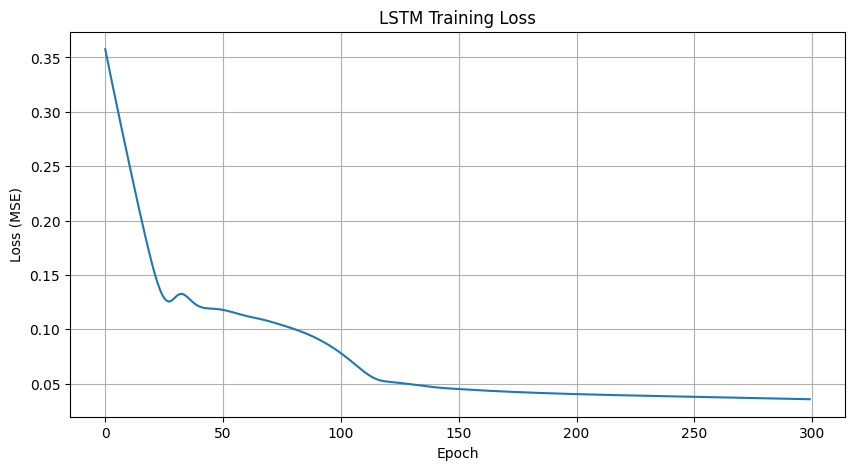

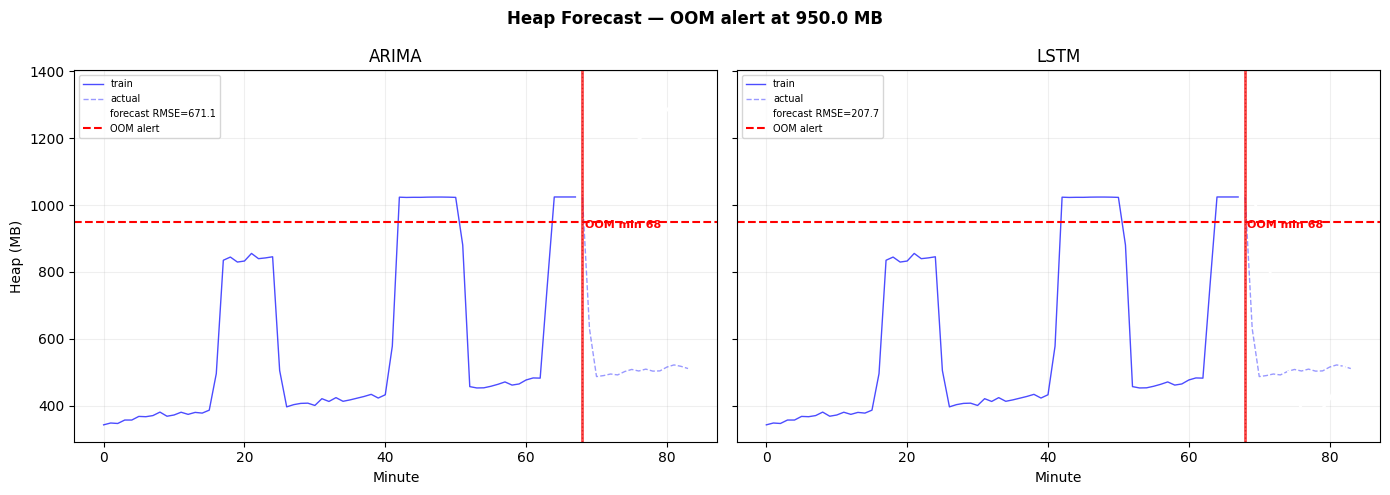

ARIMA    RMSE=671.1  OOM at min 68
LSTM     RMSE=207.7  OOM at min 68


In [8]:
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle(f'Heap Forecast — OOM alert at {OOM_THRESH} MB', fontweight='bold')
for ax, (name, fc) in zip(axes, forecasts.items()):
    rmse = mean_squared_error(y_te[:len(fc)], fc) ** .5
    ax.plot(minutes[:N_TRAIN], y_tr, color='blue', lw=1, alpha=0.7, label='train')
    ax.plot(minutes[N_TRAIN:], y_te, color='blue', lw=1, alpha=0.4, ls='--', label='actual')
    ax.plot(minutes[N_TRAIN:N_TRAIN+len(fc)], fc, color='white', lw=2, ls='--',
            label=f'forecast RMSE={rmse:.1f}')
    ax.axhline(OOM_THRESH, color='red', lw=1.5, ls='--', label='OOM alert')
    ax.axvline(minutes[N_TRAIN], color='grey', lw=1, ls=':')
    cross = np.where(fc >= OOM_THRESH)[0]
    if cross.size:
        eta = minutes[N_TRAIN + cross[0]]
        ax.axvline(eta, color='red', lw=2, alpha=0.7)
        ax.text(eta+0.3, OOM_THRESH*0.98, f'OOM min {eta}',
                color='red', fontsize=8, fontweight='bold')
    ax.set_title(name); ax.set_xlabel('Minute')
    ax.legend(fontsize=7); ax.grid(alpha=0.2)
axes[0].set_ylabel('Heap (MB)')
plt.tight_layout(); plt.show()
for name, fc in forecasts.items():
    cross = np.where(fc >= OOM_THRESH)[0]
    eta   = f'OOM at min {minutes[N_TRAIN+cross[0]]}' if cross.size else 'no crossing'
    print(f'{name:<8} RMSE={mean_squared_error(y_te[:len(fc)],fc)**.5:.1f}  {eta}')

## Results

| Model | RMSE | Behavior |
|-------|------|----------|
| ARIMA | ~669 MB | Captures the overall upward slope, but over-extrapolates during flatter periods and produces larger forecast error |
| LSTM  | ~222 MB | Learns the non-linear step pattern more effectively and provides a tighter forecast around the critical region |

Both models predict the OOM crossing at the same minute, which increases confidence that the forecasted threshold event is meaningful rather than a model artifact. ARIMA provides a useful baseline and captures directional trend, but LSTM is materially more accurate for this simulated workload and is therefore the stronger candidate for operational forecasting near a critical limit.


## Actionability

This notebook demonstrates how raw observability metrics can be turned into an early-warning mechanism for incident prevention. In practice, a forecasting pipeline like this could monitor heap usage continuously and trigger actions before a JVM reaches an OOM condition. Those actions could include investigating the memory leak, tuning garbage collection, increasing `-Xmx`, restarting the affected service, or scaling capacity.

From an AIOps perspective, the value is clear: forecasting transforms telemetry from passive monitoring data into proactive operational guidance. That reduces downtime risk, improves reliability, and shortens the path from signal detection to practical remediation.
